<a href="https://colab.research.google.com/github/jood8/Fake-Job-Posting-Detection/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import  Embedding, Dense, Dropout, GlobalAveragePooling2D,concatenate,Conv2D,MaxPooling2D,GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
!pip install opencv-python
import cv2
import os
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 891.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 136.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 22.1 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 19.3 MB/s eta 0:00:00


In [2]:
import kagglehub
path = kagglehub.dataset_download("nithin1729s/multimodal-real-fake-job-posting-prediction")

100%|██████████| 5.45G/5.45G [02:28<00:00, 39.4MB/s]

Extracting files...


In [3]:
df=pd.read_csv(path+"/fake_job_postings.csv")

In [4]:

os.listdir(path)

['images', 'fake_job_postings.csv']

In [5]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [6]:
df.shape

(17880, 18)

In [7]:
df["description"] = df["description"].fillna("")
df["requirements"] = df["requirements"].fillna("")
df["title"] = df["title"].fillna("")

df["text"] = (
    df["title"] + " " +
    df["description"] + " " +
    df["requirements"]
)

In [8]:
def get_image_path(row):

    label = row['fraudulent']
    job_id = row['job_id']

    return f"{path}/images/{label}/{job_id}.png"


df['image_path'] = df.apply(get_image_path, axis=1)

In [9]:
df['image_exists'] = df['image_path'].apply(os.path.exists)
df = df[df['image_exists'] == True]


In [10]:
vocab_size = 10000
max_len = 200


In [11]:
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(df["text"])
sequences = tokenizer.texts_to_sequences(df["text"])
X_text_all = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post'
)

In [12]:
IMG_SIZE = 128

images = []

for img_path in df['image_path']:

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    images.append(img)

X_image_all = np.array(images) / 255.0

In [13]:
y = df['fraudulent'].values

In [14]:
X_text_train, X_text_test, X_img_train, X_img_test, y_train, y_test = train_test_split(
    X_text_all, X_image_all,  y, test_size=0.2, random_state=42, stratify=y)

In [15]:
from tensorflow.keras.layers import Input
from tensorflow.keras.applications import MobileNetV2
image_input = Input(shape=(128,128,3))

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_tensor=image_input
)

base_model.trainable = False

/tmp/ipykernel_538/4171369308.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [16]:
x = base_model.output
x=Conv2D( 32,(3,3),activation="relu",padding="same",name="conv_1")(x)
x=MaxPooling2D((2,2),name="maxPool_1")(x)
x=Conv2D( 64,(3,3),activation="relu",padding="same",name="conv_2")(x)
x=MaxPooling2D((2,2),name="maxPool_2")(x)
x = GlobalAveragePooling2D()(x)
img_features = Dense(64, activation='relu')(x)

In [17]:
df['image_exists'] = df['image_path'].apply(os.path.exists)
df['image_exists'].value_counts()

,count
image_exists,
True,17796


In [18]:
text_input = Input(shape=(max_len,))
text_features = Embedding(input_dim=vocab_size, output_dim=128)(text_input)
text_features = GlobalAveragePooling1D()(text_features)
text_features = Dense(64, activation='relu')(text_features)
text_features = Dropout(0.3)(text_features)

In [19]:
from tensorflow.keras.layers import Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
combined = Concatenate()([img_features,text_features])


In [20]:
x = Dense( 64,activation='relu')(combined)
x = Dropout(0.3)(x)
output = Dense(1,activation='sigmoid')(x)

In [21]:
model = Model( inputs=[image_input, text_input],outputs=output)

In [22]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
er=tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [23]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 3,945,889 (15.05 MB)

 Trainable params: 1,687,905 (6.44 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [24]:
history = model.fit([X_img_train, X_text_train], y_train,validation_data=([X_img_test, X_text_test], y_test ),epochs=100,batch_size=32,callbacks=[er])

Epoch 1/100
445/445 ━━━━━━━━━━━━━━━━━━━━ 116s 242ms/step - accuracy: 0.9539 - loss: 0.1550 - val_accuracy: 0.9677 - val_loss: 0.0982
Epoch 2/100
445/445 ━━━━━━━━━━━━━━━━━━━━ 105s 237ms/step - accuracy: 0.9749 - loss: 0.0752 - val_accuracy: 0.9728 - val_loss: 0.0755
Epoch 3/100
445/445 ━━━━━━━━━━━━━━━━━━━━ 105s 236ms/step - accuracy: 0.9855 - loss: 0.0446 - val_accuracy: 0.9744 - val_loss: 0.0904
Epoch 4/100
445/445 ━━━━━━━━━━━━━━━━━━━━ 104s 235ms/step - accuracy: 0.9893 - loss: 0.0300 - val_accuracy: 0.9784 - val_loss: 0.0774
Epoch 5/100
445/445 ━━━━━━━━━━━━━━━━━━━━ 103s 233ms/step - accuracy: 0.9926 - loss: 0.0218 - val_accuracy: 0.9702 - val_loss: 0.0919


In [25]:
loss, accuracy = model.evaluate( [X_img_test, X_text_test],  y_test)
print("Accuracy:", accuracy)

112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 166ms/step - accuracy: 0.9728 - loss: 0.0755
Accuracy: 0.9727528095245361


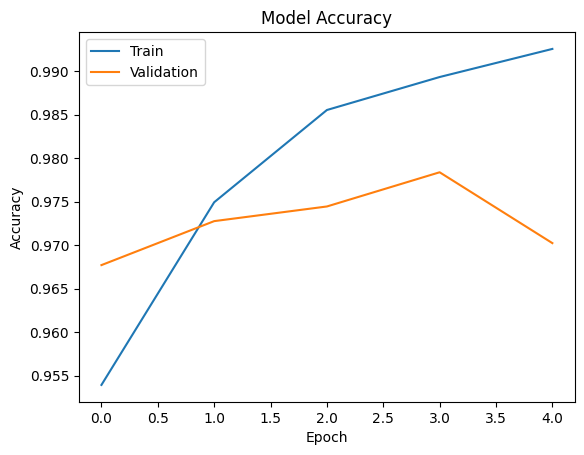

In [26]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.savefig('accuracy_multimodal.png')
plt.show()


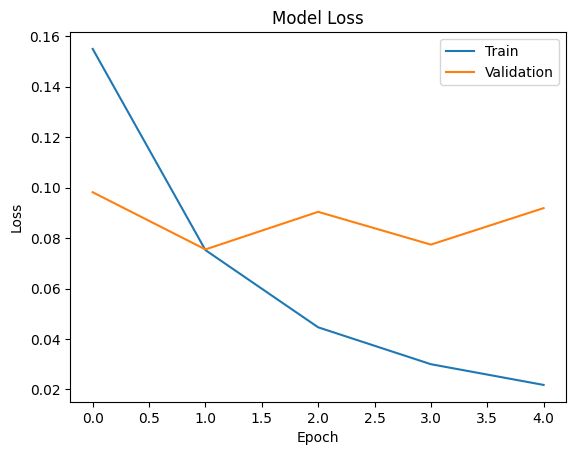

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.savefig('loss.png')
plt.show()


In [35]:
model.save("fake_job_multimodal_model.keras")

112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 176ms/step


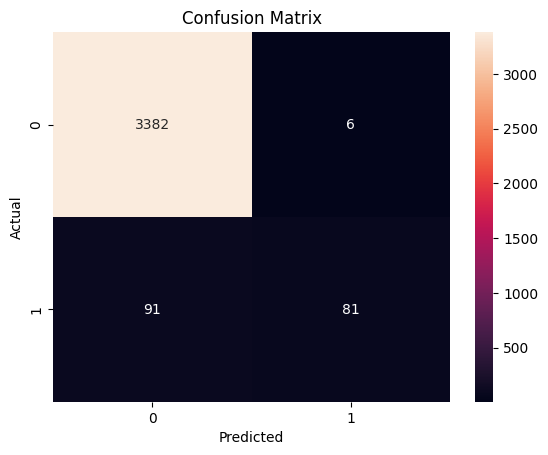

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred = model.predict([X_img_test, X_text_test])
y_pred = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('confusion_matrix.png')
plt.show()


In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3388
           1       0.93      0.47      0.63       172

    accuracy                           0.97      3560
   macro avg       0.95      0.73      0.81      3560
weighted avg       0.97      0.97      0.97      3560



In [32]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [39]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/fake_job_multimodal_model.keras",
    compile=False
)

model.save("/content/streamlit_fixed.keras")